# Detection and Scoring of Forward Runs from Broadcast-Style Tracking Data

## Contexte

Dans le football, de nombreux comportements à forte valeur tactique ne sont pas capturés par les statistiques classiques.  
Les courses sans ballon, les projections vers l’avant ou les appels dans l’espace influencent fortement la qualité offensive d’une équipe, mais restent difficiles à mesurer de manière systématique.

Ce notebook présente un prototype d’analyse construit à partir du dataset **Metrica Sports Sample Data**, qui reproduit un format proche du tracking broadcast :
- positions des joueurs,
- position du ballon,
- données temporelles à 25 images par seconde,
- fichier d’événements décrivant les actions de match.

## Objectif

L’objectif de ce projet est de construire une première pipeline capable de :

- charger et nettoyer les données de tracking,
- calculer des vitesses joueur,
- détecter des séquences de course rapide,
- filtrer les courses réellement orientées vers l’avant,
- ajouter un premier niveau de contexte événementiel,
- construire un score simple de qualité de course,
- agréger les résultats au niveau joueur.

L’ensemble vise à démontrer la faisabilité d’une approche de **football game intelligence** à partir de tracking data spatio-temporelles.

In [4]:
import pandas as pd
from pathlib import Path

data_dir = Path(r"C:\Users\jayso\Documents\Projet_SkillCorner\data")

def load_metrica_tracking(csv_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(csv_path, header=None, low_memory=False)

    # 3 lignes d'en-tête Metrica
    row2 = raw.iloc[2]

    columns = []
    current_player = None

    for i in range(raw.shape[1]):
        if i == 0:
            columns.append("Period")
        elif i == 1:
            columns.append("Frame")
        elif i == 2:
            columns.append("Time [s]")
        elif i == raw.shape[1] - 2:
            columns.append("Ball_x")
        elif i == raw.shape[1] - 1:
            columns.append("Ball_y")
        else:
            val = row2[i]

            if pd.notna(val):
                current_player = str(val)
                columns.append(f"{current_player}_x")
            else:
                if current_player is not None:
                    columns.append(f"{current_player}_y")
                else:
                    columns.append(f"unknown_{i}")

    df = raw.iloc[3:].copy()
    df.columns = columns
    df.reset_index(drop=True, inplace=True)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def load_metrica_events(csv_path: Path) -> pd.DataFrame:
    return pd.read_csv(csv_path)


home = load_metrica_tracking(data_dir / "Sample_Game_1_RawTrackingData_Home_Team.csv")
away = load_metrica_tracking(data_dir / "Sample_Game_1_RawTrackingData_Away_Team.csv")
events = load_metrica_events(data_dir / "Sample_Game_1_RawEventsData.csv")

print(home.head())
print(home.columns.tolist())
print(away.head())
print(events.head())

   Period  Frame  Time [s]  Player11_x  Player11_y  Player1_x  Player1_y  \
0       1      1      0.04     0.00082     0.48238    0.32648    0.65322   
1       1      2      0.08     0.00096     0.48238    0.32648    0.65322   
2       1      3      0.12     0.00114     0.48238    0.32648    0.65322   
3       1      4      0.16     0.00121     0.48238    0.32622    0.65317   
4       1      5      0.20     0.00129     0.48238    0.32597    0.65269   

   Player2_x  Player2_y  Player3_x  ...  Player10_x  Player10_y  Player12_x  \
0    0.33701    0.48863    0.30927  ...     0.55243     0.43269         NaN   
1    0.33701    0.48863    0.30927  ...     0.55243     0.43269         NaN   
2    0.33701    0.48863    0.30927  ...     0.55243     0.43269         NaN   
3    0.33687    0.48988    0.30944  ...     0.55236     0.43313         NaN   
4    0.33664    0.49018    0.30948  ...     0.55202     0.43311         NaN   

   Player12_y  Player13_x  Player13_y  Player14_x  Player14_y   Ball

# Étape 2 — Inspection des données

Maintenant que les fichiers Metrica sont correctement chargés, l’objectif est de comprendre la structure des données.

On veut répondre à quatre questions simples :

1. Combien de lignes et de colonnes contient chaque DataFrame ?
2. Quels sont les noms de colonnes ?
3. Quels joueurs sont présents dans les données home et away ?
4. Y a-t-il des valeurs manquantes importantes ?

Cette étape est essentielle avant tout calcul de vitesse, de distance ou de métriques tactiques.

In [5]:
print("HOME shape :", home.shape)
print("AWAY shape :", away.shape)
print("EVENTS shape :", events.shape)

print("\nColonnes HOME :")
print(home.columns.tolist())

print("\nColonnes AWAY :")
print(away.columns.tolist())

print("\nAperçu HOME :")
display(home.head())

print("\nAperçu AWAY :")
display(away.head())

print("\nAperçu EVENTS :")
display(events.head())

HOME shape : (145006, 33)
AWAY shape : (145006, 33)
EVENTS shape : (1745, 14)

Colonnes HOME :
['Period', 'Frame', 'Time [s]', 'Player11_x', 'Player11_y', 'Player1_x', 'Player1_y', 'Player2_x', 'Player2_y', 'Player3_x', 'Player3_y', 'Player4_x', 'Player4_y', 'Player5_x', 'Player5_y', 'Player6_x', 'Player6_y', 'Player7_x', 'Player7_y', 'Player8_x', 'Player8_y', 'Player9_x', 'Player9_y', 'Player10_x', 'Player10_y', 'Player12_x', 'Player12_y', 'Player13_x', 'Player13_y', 'Player14_x', 'Player14_y', 'Ball_x', 'Ball_y']

Colonnes AWAY :
['Period', 'Frame', 'Time [s]', 'Player25_x', 'Player25_y', 'Player15_x', 'Player15_y', 'Player16_x', 'Player16_y', 'Player17_x', 'Player17_y', 'Player18_x', 'Player18_y', 'Player19_x', 'Player19_y', 'Player20_x', 'Player20_y', 'Player21_x', 'Player21_y', 'Player22_x', 'Player22_y', 'Player23_x', 'Player23_y', 'Player24_x', 'Player24_y', 'Player26_x', 'Player26_y', 'Player27_x', 'Player27_y', 'Player28_x', 'Player28_y', 'Ball_x', 'Ball_y']

Aperçu HOME :


,Period,Frame,Time [s],Player11_x,Player11_y,Player1_x,Player1_y,Player2_x,Player2_y,Player3_x,...,Player10_x,Player10_y,Player12_x,Player12_y,Player13_x,Player13_y,Player14_x,Player14_y,Ball_x,Ball_y
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570



Aperçu AWAY :


,Period,Frame,Time [s],Player25_x,Player25_y,Player15_x,Player15_y,Player16_x,Player16_y,Player17_x,...,Player24_x,Player24_y,Player26_x,Player26_y,Player27_x,Player27_y,Player28_x,Player28_y,Ball_x,Ball_y
0,1,1,0.04,0.90509,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.90494,0.47462,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.90434,0.47463,0.58393,0.20794,0.67658,0.46710,0.67310,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.90377,0.47463,0.58351,0.20868,0.67640,0.46762,0.67279,...,0.37756,0.27473,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.90324,0.47464,0.58291,0.21039,0.67599,0.46769,0.67253,...,0.37663,0.27543,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570



Aperçu EVENTS :


,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47


## Étape 2.2 — Identifier les joueurs disponibles

Les colonnes de tracking sont organisées sous la forme `PlayerX_x` et `PlayerX_y`.

Pour travailler plus facilement, on extrait automatiquement la liste des joueurs présents dans les données home et away.

Cela nous sera utile plus tard pour :
- calculer les vitesses,
- calculer les distances,
- parcourir tous les joueurs dans des boucles.

In [6]:
home_players = sorted({
    col[:-2] for col in home.columns
    if col.startswith("Player") and col.endswith("_x")
})

away_players = sorted({
    col[:-2] for col in away.columns
    if col.startswith("Player") and col.endswith("_x")
})

print("Joueurs HOME :")
print(home_players)

print("\nJoueurs AWAY :")
print(away_players)

Joueurs HOME :
['Player1', 'Player10', 'Player11', 'Player12', 'Player13', 'Player14', 'Player2', 'Player3', 'Player4', 'Player5', 'Player6', 'Player7', 'Player8', 'Player9']

Joueurs AWAY :
['Player15', 'Player16', 'Player17', 'Player18', 'Player19', 'Player20', 'Player21', 'Player22', 'Player23', 'Player24', 'Player25', 'Player26', 'Player27', 'Player28']


## Étape 2.3 — Vérifier les valeurs manquantes

Certaines colonnes joueurs peuvent contenir des valeurs manquantes (`NaN`).

Cela peut arriver si un joueur n’est pas suivi à certains instants, ou si certaines colonnes ne sont pas renseignées dans le sample.

Avant de construire des métriques, il faut identifier les colonnes les plus incomplètes.

In [7]:
missing_home = home.isna().sum().sort_values(ascending=False)
missing_away = away.isna().sum().sort_values(ascending=False)

print("Colonnes HOME avec le plus de valeurs manquantes :")
display(missing_home.head(15))

print("Colonnes AWAY avec le plus de valeurs manquantes :")
display(missing_away.head(15))

Colonnes HOME avec le plus de valeurs manquantes :


Player14_y    121391
Player14_x    121391
Player13_y    110848
Player13_x    110848
Player1_y      98300
Player1_x      98300
Ball_x         56755
Ball_y         56755
Player12_x     46705
Player12_y     46705
Player6_y      34157
Player6_x      34157
Player10_x     23614
Player10_y     23614
Period             0
dtype: int64

Colonnes AWAY avec le plus de valeurs manquantes :


Player28_y    119380
Player28_x    119380
Player27_y    106868
Player27_x    106868
Player26_x    106598
Player26_y    106598
Ball_x         56755
Ball_y         56755
Player24_x     38407
Player24_y     38407
Player22_y     38137
Player22_x     38137
Player19_x     25625
Player19_y     25625
Period             0
dtype: int64

# 1. Données utilisées

Le projet repose sur les fichiers du **Sample Game 1** du dataset Metrica Sports :

- `Sample_Game_1_RawTrackingData_Home_Team.csv`
- `Sample_Game_1_RawTrackingData_Away_Team.csv`
- `Sample_Game_1_RawEventsData.csv`

## Structure des données

Les fichiers de tracking contiennent :
- la période du match,
- le numéro de frame,
- le temps en secondes,
- les coordonnées `(x, y)` de chaque joueur,
- les coordonnées `(x, y)` du ballon.

Le fichier d’événements contient :
- l’équipe concernée,
- le type d’action (`PASS`, `RECOVERY`, `BALL LOST`, etc.),
- les frames de début et de fin,
- les joueurs impliqués.

## Taille du dataset

Dans ce notebook :
- `home.shape = (145006, 33)`
- `away.shape = (145006, 33)`
- `events.shape = (1745, 14)`

Ces données permettent de travailler à la fois sur :
- la dynamique spatio-temporelle des joueurs,
- et le contexte de jeu via les événements.

# Étape 3 — Fusion des données home et away

Les données tracking sont séparées en deux fichiers :
- un fichier pour l’équipe à domicile,
- un fichier pour l’équipe à l’extérieur.

Pour pouvoir analyser les interactions entre les deux équipes, on doit fusionner ces deux tables dans un seul DataFrame.

L’objectif est d’obtenir, pour chaque frame :
- les positions de tous les joueurs,
- la position du ballon,
- les informations temporelles communes (`Period`, `Frame`, `Time [s]`).

Cette fusion est indispensable pour construire des métriques tactiques comme :
- la distance entre un attaquant et la ligne défensive adverse,
- les situations entre les lignes,
- les comportements de pressing.

In [8]:
tracking = pd.merge(
    home,
    away,
    on=["Period", "Frame", "Time [s]"],
    how="inner",
    suffixes=("_home", "_away")
)

print("TRACKING shape :", tracking.shape)
display(tracking.head())

TRACKING shape : (145006, 63)


,Period,Frame,Time [s],Player11_x,Player11_y,Player1_x,Player1_y,Player2_x,Player2_y,Player3_x,...,Player24_x,Player24_y,Player26_x,Player26_y,Player27_x,Player27_y,Player28_x,Player28_y,Ball_x_away,Ball_y_away
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.37756,0.27473,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.37663,0.27543,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


## Étape 3.2 — Uniformiser la position du ballon

Après la fusion, la position du ballon apparaît en double :
- une fois depuis le fichier home,
- une fois depuis le fichier away.

Comme il s’agit du même ballon, on crée une seule version finale :
- `Ball_x`
- `Ball_y`

On prend la valeur home si elle existe, sinon la valeur away.

In [9]:
tracking["Ball_x"] = tracking["Ball_x_home"].fillna(tracking["Ball_x_away"])
tracking["Ball_y"] = tracking["Ball_y_home"].fillna(tracking["Ball_y_away"])

print(tracking[["Ball_x_home", "Ball_x_away", "Ball_x", "Ball_y_home", "Ball_y_away", "Ball_y"]].head())

   Ball_x_home  Ball_x_away   Ball_x  Ball_y_home  Ball_y_away   Ball_y
0      0.45472      0.45472  0.45472      0.38709      0.38709  0.38709
1      0.49645      0.49645  0.49645      0.40656      0.40656  0.40656
2      0.53716      0.53716  0.53716      0.42556      0.42556  0.42556
3      0.55346      0.55346  0.55346      0.42231      0.42231  0.42231
4      0.55512      0.55512  0.55512      0.40570      0.40570  0.40570


## Étape 3.3 — Supprimer les doublons du ballon

Une fois les colonnes `Ball_x` et `Ball_y` créées, les anciennes colonnes du ballon issues des tables home et away ne sont plus nécessaires.

On les supprime pour simplifier le DataFrame final.

In [10]:
tracking = tracking.drop(columns=["Ball_x_home", "Ball_y_home", "Ball_x_away", "Ball_y_away"])

print("Colonnes finales :")
print(tracking.columns.tolist())

print("\nAperçu final :")
display(tracking.head())

Colonnes finales :
['Period', 'Frame', 'Time [s]', 'Player11_x', 'Player11_y', 'Player1_x', 'Player1_y', 'Player2_x', 'Player2_y', 'Player3_x', 'Player3_y', 'Player4_x', 'Player4_y', 'Player5_x', 'Player5_y', 'Player6_x', 'Player6_y', 'Player7_x', 'Player7_y', 'Player8_x', 'Player8_y', 'Player9_x', 'Player9_y', 'Player10_x', 'Player10_y', 'Player12_x', 'Player12_y', 'Player13_x', 'Player13_y', 'Player14_x', 'Player14_y', 'Player25_x', 'Player25_y', 'Player15_x', 'Player15_y', 'Player16_x', 'Player16_y', 'Player17_x', 'Player17_y', 'Player18_x', 'Player18_y', 'Player19_x', 'Player19_y', 'Player20_x', 'Player20_y', 'Player21_x', 'Player21_y', 'Player22_x', 'Player22_y', 'Player23_x', 'Player23_y', 'Player24_x', 'Player24_y', 'Player26_x', 'Player26_y', 'Player27_x', 'Player27_y', 'Player28_x', 'Player28_y', 'Ball_x', 'Ball_y']

Aperçu final :


,Period,Frame,Time [s],Player11_x,Player11_y,Player1_x,Player1_y,Player2_x,Player2_y,Player3_x,...,Player24_x,Player24_y,Player26_x,Player26_y,Player27_x,Player27_y,Player28_x,Player28_y,Ball_x,Ball_y
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.37833,0.27383,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.37756,0.27473,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.37663,0.27543,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


# 2. Préparation des données

## 2.1 Parsing du format Metrica

Les fichiers de tracking Metrica contiennent plusieurs lignes d’en-tête.  
Une étape spécifique a donc été nécessaire pour :

- reconstruire les noms de colonnes,
- obtenir des colonnes du type `PlayerX_x`, `PlayerX_y`,
- identifier correctement la position du ballon.

## 2.2 Fusion des deux équipes

Les données `home` et `away` ont ensuite été fusionnées sur :

- `Period`
- `Frame`
- `Time [s]`

afin d’obtenir un seul DataFrame contenant :
- les positions des deux équipes,
- la position du ballon,
- les informations temporelles communes.

## 2.3 Conversion en mètres

Les coordonnées initiales du dataset sont normalisées entre `0` et `1`.  
Pour rendre l’analyse plus interprétable, elles ont été converties en mètres en supposant un terrain standard de :

- **105 m** en longueur,
- **68 m** en largeur.

Cette conversion est indispensable pour :
- calculer des vitesses réalistes,
- mesurer des distances de course,
- interpréter les séquences de manière footballistique.

# Étape 4 — Conversion des coordonnées en mètres

Les coordonnées du dataset Metrica sont exprimées dans un repère normalisé entre 0 et 1.

Pour rendre les analyses plus interprétables, on convertit les coordonnées en mètres en supposant un terrain standard de football :
- 105 mètres de longueur,
- 68 mètres de largeur.

Cette étape est importante pour :
- interpréter les distances de manière réaliste,
- calculer ensuite des vitesses en m/s,
- produire des métriques tactiques plus compréhensibles.

In [11]:
def convert_to_metric_coordinates(df, field_length=105, field_width=68):
    df = df.copy()

    x_cols = [col for col in df.columns if col.endswith("_x")]
    y_cols = [col for col in df.columns if col.endswith("_y")]

    for col in x_cols:
        df[col] = df[col] * field_length

    for col in y_cols:
        df[col] = df[col] * field_width

    return df

## Étape 4.2 — Application de la conversion

On applique maintenant la conversion au DataFrame `tracking`.

On compare ensuite quelques colonnes avant et après conversion pour vérifier que les coordonnées ont bien changé d’échelle.

In [12]:
tracking_m = convert_to_metric_coordinates(tracking)

print("Aperçu avant conversion :")
display(tracking[["Player11_x", "Player11_y", "Ball_x", "Ball_y"]].head())

print("Aperçu après conversion en mètres :")
display(tracking_m[["Player11_x", "Player11_y", "Ball_x", "Ball_y"]].head())

Aperçu avant conversion :


,Player11_x,Player11_y,Ball_x,Ball_y
0,0.00082,0.48238,0.45472,0.38709
1,0.00096,0.48238,0.49645,0.40656
2,0.00114,0.48238,0.53716,0.42556
3,0.00121,0.48238,0.55346,0.42231
4,0.00129,0.48238,0.55512,0.40570


Aperçu après conversion en mètres :


,Player11_x,Player11_y,Ball_x,Ball_y
0,0.08610,32.80184,47.74560,26.32212
1,0.10080,32.80184,52.12725,27.64608
2,0.11970,32.80184,56.40180,28.93808
3,0.12705,32.80184,58.11330,28.71708
4,0.13545,32.80184,58.28760,27.58760


## Étape 4.3 — Vérification des bornes

Après conversion, on vérifie que les coordonnées obtenues sont cohérentes avec les dimensions du terrain.

On s’attend globalement à avoir :
- des coordonnées `x` entre 0 et 105,
- des coordonnées `y` entre 0 et 68.

In [13]:
x_cols = [col for col in tracking_m.columns if col.endswith("_x")]
y_cols = [col for col in tracking_m.columns if col.endswith("_y")]

print("Bornes globales sur les x :")
print("min =", tracking_m[x_cols].min().min())
print("max =", tracking_m[x_cols].max().max())

print("\nBornes globales sur les y :")
print("min =", tracking_m[y_cols].min().min())
print("max =", tracking_m[y_cols].max().max())

Bornes globales sur les x :
min = -4.7754
max = 111.2958

Bornes globales sur les y :
min = -3.4000000000000004
max = 71.4


# 3. Calcul des vitesses et contrôle qualité

## 3.1 Calcul des vitesses

Les vitesses ont été calculées à partir des différences de position entre deux frames consécutives :

- `vx = Δx / Δt`
- `vy = Δy / Δt`
- `speed = sqrt(vx² + vy²)`

Le pas de temps du dataset est de **0.04 seconde** (25 frames par seconde).

## 3.2 Détection d’anomalies

Lors de l’exploration initiale, certaines vitesses aberrantes ont été observées.  
Par exemple, un pic à plus de **2000 m/s** est apparu pour `Player11`, ce qui est physiquement impossible.

L’inspection locale a montré qu’il s’agissait d’un **artefact du tracking**, lié à un saut brutal de coordonnées entre deux frames.

## 3.3 Nettoyage des vitesses

Pour éviter que ces anomalies ne perturbent l’analyse, un seuil de vitesse maximale réaliste a été fixé :

- `max_speed_threshold = 12 m/s`

Toute vitesse supérieure à ce seuil a été remplacée par `NaN`.

## 3.4 Remarque méthodologique

Le notebook montre également que le **lissage seul** ne suffit pas à supprimer ce type d’anomalie.  
Si une coordonnée aberrante est présente, le lissage peut même étaler le problème sur plusieurs frames voisines.

Cette observation est importante :  
dans un pipeline de tracking, le contrôle qualité explicite reste indispensable avant toute interprétation tactique.

# Étape 5 — Calcul de la vitesse d’un joueur

Le tracking fournit les positions des joueurs à chaque frame.

Pour analyser les déplacements, on veut calculer la vitesse à partir de ces positions.

Dans un premier temps, on commence avec un seul joueur (`Player11`) pour comprendre le principe.

La vitesse sur chaque axe est calculée comme :

- vitesse en x = variation de x / variation du temps
- vitesse en y = variation de y / variation du temps

Puis la vitesse totale est obtenue par la norme :

speed = sqrt(vx² + vy²)

Le pas de temps du dataset est de 0.04 seconde (25 frames par seconde).

In [14]:
import numpy as np

dt = 0.04  # 25 frames par seconde

tracking_m["Player11_vx"] = tracking_m["Player11_x"].diff() / dt
tracking_m["Player11_vy"] = tracking_m["Player11_y"].diff() / dt

tracking_m["Player11_speed"] = np.sqrt(
    tracking_m["Player11_vx"]**2 + tracking_m["Player11_vy"]**2
)

display(
    tracking_m[
        ["Frame", "Time [s]", "Player11_x", "Player11_y", "Player11_vx", "Player11_vy", "Player11_speed"]
    ].head(10)
)

,Frame,Time [s],Player11_x,Player11_y,Player11_vx,Player11_vy,Player11_speed
0,1,0.04,0.08610,32.80184,NaN,NaN,NaN
1,2,0.08,0.10080,32.80184,0.36750,0.000,0.367500
2,3,0.12,0.11970,32.80184,0.47250,0.000,0.472500
3,4,0.16,0.12705,32.80184,0.18375,0.000,0.183750
4,5,0.20,0.13545,32.80184,0.21000,0.000,0.210000
5,6,0.24,0.14700,32.80184,0.28875,0.000,0.288750
6,7,0.28,0.14700,32.80184,0.00000,0.000,0.000000
7,8,0.32,0.14700,32.80184,0.00000,0.000,0.000000
8,9,0.36,0.12600,32.77124,-0.52500,-0.765,0.927820
9,10,0.40,0.10500,32.73996,-0.52500,-0.782,0.941886


## Étape 5.2 — Résumé statistique de la vitesse

Après avoir calculé la vitesse frame par frame pour `Player11`, on résume cette variable avec quelques statistiques simples.

L’objectif est de mieux comprendre l’ordre de grandeur des vitesses observées :
- moyenne,
- médiane,
- minimum,
- maximum.

Cela permet de vérifier que le calcul fonctionne et de préparer la suite du projet.

In [15]:
player11_speed_stats = tracking_m["Player11_speed"].describe()

print("Statistiques sur la vitesse de Player11 :")
print(player11_speed_stats)

Statistiques sur la vitesse de Player11 :
count    145005.000000
mean          0.665755
std           6.019244
min           0.000000
25%           0.201583
50%           0.550879
75%           0.957773
max        2281.614353
Name: Player11_speed, dtype: float64


## Étape 5.3 — Identifier les pics de vitesse

On trie maintenant les frames selon la vitesse de `Player11` pour repérer les moments où il se déplace le plus rapidement.

Cette étape servira plus tard à détecter des courses, des accélérations ou des séquences tactiques intéressantes.

In [16]:
top_speed_frames = tracking_m[
    ["Frame", "Time [s]", "Player11_x", "Player11_y", "Player11_speed"]
].sort_values("Player11_speed", ascending=False)

print("Frames où Player11 va le plus vite :")
display(top_speed_frames.head(10))

Frames où Player11 va le plus vite :


,Frame,Time [s],Player11_x,Player11_y,Player11_speed
71268,71269,2850.76,106.34295,32.16604,2281.614353
40036,40037,1601.48,1.77030,38.24252,9.471282
40035,40036,1601.44,2.02755,38.52064,9.392913
104299,104300,4172.00,102.51570,42.89644,9.373727
40034,40035,1601.40,2.28165,38.79740,9.325108
104313,104314,4172.56,102.73830,46.35084,9.293718
40033,40034,1601.36,2.53470,39.07144,9.252024
40032,40033,1601.32,2.78565,39.34344,9.161169
104303,104304,4172.16,102.69630,44.24692,9.112906
40031,40032,1601.28,3.03345,39.61340,9.105860


## Étape 5.4 — Inspection d’une vitesse aberrante

La vitesse maximale observée pour `Player11` est irréaliste (`2281 m/s`), ce qui indique un artefact dans les données.

Avant de corriger ce problème, on inspecte les frames autour de cette anomalie pour comprendre ce qui se passe dans les coordonnées du joueur.

In [17]:
anomaly_idx = tracking_m["Player11_speed"].idxmax()

cols_to_check = [
    "Frame", "Time [s]",
    "Player11_x", "Player11_y",
    "Player11_vx", "Player11_vy", "Player11_speed"
]

print("Index de l'anomalie :", anomaly_idx)
display(tracking_m.loc[anomaly_idx-3:anomaly_idx+3, cols_to_check])

Index de l'anomalie : 71268


,Frame,Time [s],Player11_x,Player11_y,Player11_vx,Player11_vy,Player11_speed
71265,71266,2850.64,16.10700,45.93332,0.39375,0.000,0.393750
71266,71267,2850.68,16.12275,45.93332,0.39375,0.000,0.393750
71267,71268,2850.72,16.12275,45.93332,0.00000,0.000,0.000000
71268,71269,2850.76,106.34295,32.16604,2255.50500,-344.182,2281.614353
71269,71270,2850.80,106.34295,32.16604,0.00000,0.000,0.000000
71270,71271,2850.84,106.34295,32.16604,0.00000,0.000,0.000000
71271,71272,2850.88,106.34085,32.16604,-0.05250,0.000,0.052500


## Étape 5.5 — Nettoyage des vitesses aberrantes

Certaines vitesses calculées à partir du tracking peuvent être irréalistes à cause de sauts artificiels dans les coordonnées.

Pour éviter que ces anomalies perturbent l’analyse, on fixe un seuil maximal de vitesse réaliste.

Dans ce notebook, on considère qu’une vitesse supérieure à 12 m/s est aberrante, et on la remplace par une valeur manquante (`NaN`).

In [18]:
max_speed_threshold = 12  # m/s

tracking_m["Player11_speed_clean"] = tracking_m["Player11_speed"].where(
    tracking_m["Player11_speed"] <= max_speed_threshold,
    np.nan
)

print("Statistiques sur la vitesse brute de Player11 :")
print(tracking_m["Player11_speed"].describe())

print("\nStatistiques sur la vitesse nettoyée de Player11 :")
print(tracking_m["Player11_speed_clean"].describe())

Statistiques sur la vitesse brute de Player11 :
count    145005.000000
mean          0.665755
std           6.019244
min           0.000000
25%           0.201583
50%           0.550879
75%           0.957773
max        2281.614353
Name: Player11_speed, dtype: float64

Statistiques sur la vitesse nettoyée de Player11 :
count    145004.000000
mean          0.650025
std           0.592594
min           0.000000
25%           0.201583
50%           0.550879
75%           0.957773
max           9.471282
Name: Player11_speed_clean, dtype: float64


## Étape 5.6 — Vérification après nettoyage

Après nettoyage, on réaffiche les plus grandes vitesses observées pour vérifier que les valeurs restantes sont plausibles d’un point de vue physique.

In [19]:
top_speed_frames_clean = tracking_m[
    ["Frame", "Time [s]", "Player11_x", "Player11_y", "Player11_speed_clean"]
].sort_values("Player11_speed_clean", ascending=False)

print("Frames où Player11 va le plus vite après nettoyage :")
display(top_speed_frames_clean.head(10))

Frames où Player11 va le plus vite après nettoyage :


,Frame,Time [s],Player11_x,Player11_y,Player11_speed_clean
40036,40037,1601.48,1.77030,38.24252,9.471282
40035,40036,1601.44,2.02755,38.52064,9.392913
104299,104300,4172.00,102.51570,42.89644,9.373727
40034,40035,1601.40,2.28165,38.79740,9.325108
104313,104314,4172.56,102.73830,46.35084,9.293718
40033,40034,1601.36,2.53470,39.07144,9.252024
40032,40033,1601.32,2.78565,39.34344,9.161169
104303,104304,4172.16,102.69630,44.24692,9.112906
40031,40032,1601.28,3.03345,39.61340,9.105860
104296,104297,4171.88,102.34875,41.90636,8.964536


# 4. Détection des séquences de course

## 4.1 Définition d’une frame rapide

Une première règle simple a été utilisée pour détecter les moments où un joueur est en déplacement rapide :

- une frame est considérée comme "rapide" si `speed_clean > 5 m/s`

Cette étape transforme une variable continue (la vitesse) en un indicateur simple :
- le joueur court vite,
- ou il ne court pas vite.

## 4.2 Regroupement en séquences continues

Les frames rapides ont ensuite été regroupées en **séquences de course** lorsque les frames étaient consécutives.

Chaque séquence est alors résumée par :
- sa frame de début,
- sa frame de fin,
- sa durée,
- sa position de départ,
- sa position d’arrivée,
- sa vitesse maximale.

## 4.3 Variables descriptives de course

Pour caractériser chaque séquence, plusieurs variables ont été calculées :

- `delta_x` : progression longitudinale,
- `delta_y` : déplacement latéral,
- `run_distance` : distance totale de la course,
- `forward_ratio = delta_x / run_distance`

L’indicateur `forward_ratio` permet de distinguer :
- les courses très orientées vers l’avant,
- les courses latérales,
- les courses vers l’arrière.

# Étape 6 — Généralisation du calcul de vitesse à tous les joueurs

Après avoir calculé et nettoyé la vitesse de `Player11`, on généralise maintenant cette logique à tous les joueurs du match.

L’objectif est de créer automatiquement, pour chaque joueur :
- la vitesse sur l’axe x (`vx`),
- la vitesse sur l’axe y (`vy`),
- la vitesse totale (`speed`),
- une version nettoyée de la vitesse (`speed_clean`).

Cette étape est importante car les futures métriques tactiques (courses, pressing, transitions) devront être calculées pour l’ensemble des joueurs, et non pour un seul individu.

In [20]:
def add_velocity_features(df, player_list, dt=0.04, max_speed_threshold=12):
    df = df.copy()

    for player in player_list:
        x_col = f"{player}_x"
        y_col = f"{player}_y"

        vx_col = f"{player}_vx"
        vy_col = f"{player}_vy"
        speed_col = f"{player}_speed"
        speed_clean_col = f"{player}_speed_clean"

        df[vx_col] = df[x_col].diff() / dt
        df[vy_col] = df[y_col].diff() / dt

        df[speed_col] = np.sqrt(df[vx_col]**2 + df[vy_col]**2)

        df[speed_clean_col] = df[speed_col].where(
            df[speed_col] <= max_speed_threshold,
            np.nan
        )

    return df

## Étape 6.2 — Construire la liste complète des joueurs

Avant d’appliquer la fonction, on rassemble tous les joueurs présents dans les données home et away dans une seule liste.

Cette liste servira à parcourir automatiquement l’ensemble des joueurs du match.

In [21]:
all_players = sorted(home_players + away_players)

print("Nombre total de joueurs :", len(all_players))
print(all_players)

Nombre total de joueurs : 28
['Player1', 'Player10', 'Player11', 'Player12', 'Player13', 'Player14', 'Player15', 'Player16', 'Player17', 'Player18', 'Player19', 'Player2', 'Player20', 'Player21', 'Player22', 'Player23', 'Player24', 'Player25', 'Player26', 'Player27', 'Player28', 'Player3', 'Player4', 'Player5', 'Player6', 'Player7', 'Player8', 'Player9']


## Étape 6.3 — Appliquer le calcul de vitesse à tous les joueurs

On applique maintenant la fonction au DataFrame `tracking_m`, qui contient déjà les coordonnées converties en mètres.

Le résultat sera stocké dans un nouveau DataFrame enrichi.

In [22]:
tracking_v = add_velocity_features(
    tracking_m,
    all_players,
    dt=0.04,
    max_speed_threshold=12
)

print("Shape du DataFrame enrichi :", tracking_v.shape)

cols_example = [
    "Frame", "Time [s]",
    "Player11_x", "Player11_y", "Player11_vx", "Player11_vy", "Player11_speed", "Player11_speed_clean"
]

display(tracking_v[cols_example].head(10))

Shape du DataFrame enrichi : (145006, 173)


C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\2723931554.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[speed_col] = np.sqrt(df[vx_col]**2 + df[vy_col]**2)
C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\2723931554.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[speed_clean_col] = df[speed_col].where(
C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\2723931554.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

,Frame,Time [s],Player11_x,Player11_y,Player11_vx,Player11_vy,Player11_speed,Player11_speed_clean
0,1,0.04,0.08610,32.80184,NaN,NaN,NaN,NaN
1,2,0.08,0.10080,32.80184,0.36750,0.000,0.367500,0.367500
2,3,0.12,0.11970,32.80184,0.47250,0.000,0.472500,0.472500
3,4,0.16,0.12705,32.80184,0.18375,0.000,0.183750,0.183750
4,5,0.20,0.13545,32.80184,0.21000,0.000,0.210000,0.210000
5,6,0.24,0.14700,32.80184,0.28875,0.000,0.288750,0.288750
6,7,0.28,0.14700,32.80184,0.00000,0.000,0.000000,0.000000
7,8,0.32,0.14700,32.80184,0.00000,0.000,0.000000,0.000000
8,9,0.36,0.12600,32.77124,-0.52500,-0.765,0.927820,0.927820
9,10,0.40,0.10500,32.73996,-0.52500,-0.782,0.941886,0.941886


## Étape 6.4 — Comparer les vitesses maximales des joueurs

Après avoir calculé les vitesses pour tous les joueurs, on résume maintenant une information simple : la vitesse maximale nettoyée de chaque joueur.

Cette étape permet de vérifier que :
- les calculs sont cohérents pour l’ensemble des joueurs,
- les vitesses observées restent plausibles,
- aucune anomalie évidente ne subsiste dans les résultats.

In [23]:
max_speeds = {}

for player in all_players:
    speed_clean_col = f"{player}_speed_clean"
    max_speeds[player] = tracking_v[speed_clean_col].max()

max_speeds_df = (
    pd.DataFrame.from_dict(max_speeds, orient="index", columns=["max_speed_clean"])
    .sort_values("max_speed_clean", ascending=False)
    .reset_index()
    .rename(columns={"index": "player"})
)

display(max_speeds_df)

,player,max_speed_clean
0,Player9,11.988067
1,Player10,11.976406
2,Player17,11.974350
3,Player20,11.974144
4,Player2,11.949788
5,Player8,11.912032
6,Player15,11.894069
7,Player5,11.885131
8,Player18,11.846085
9,Player23,11.617800


# 5. Filtrage des forward runs stricts

Toutes les courses rapides ne correspondent pas à des projections offensives pertinentes.

Un filtre plus strict a donc été appliqué pour ne conserver que les séquences qui respectent simultanément les conditions suivantes :

- `duration_s >= 0.20`
- `run_distance >= 1.0`
- `delta_x > 0.5`
- `forward_ratio >= 0.7`

## Interprétation

Cette définition permet de conserver uniquement des courses qui :
- durent suffisamment longtemps,
- couvrent une distance minimale,
- progressent réellement vers l’avant,
- sont majoritairement orientées dans cette direction.

Ces séquences sont appelées ici **forward runs strictes**.

## Exemple exploratoire

Pour `Player11`, cette méthode a permis d’identifier **3 forward runs strictes**, dont une particulièrement intéressante car associée à une passe reçue de son équipe.

# Étape 7 — Lissage des positions avant calcul de vitesse

Les coordonnées de tracking peuvent contenir du bruit ou de petites variations irrégulières d’une frame à l’autre.

Or, comme la vitesse est calculée à partir des différences de position, ce bruit peut produire des pics artificiels.

Pour améliorer la qualité des vitesses calculées, on commence par lisser les trajectoires des joueurs.

Dans un premier temps, on applique ce lissage à un seul joueur (`Player11`) afin de comparer :
- les positions brutes,
- les positions lissées,
- les vitesses obtenues dans les deux cas.

In [24]:
window = 5  # taille de la fenêtre de lissage

tracking_v["Player11_x_smooth"] = tracking_v["Player11_x"].rolling(
    window=window, center=True, min_periods=1
).mean()

tracking_v["Player11_y_smooth"] = tracking_v["Player11_y"].rolling(
    window=window, center=True, min_periods=1
).mean()

display(
    tracking_v[
        ["Frame", "Time [s]", "Player11_x", "Player11_x_smooth", "Player11_y", "Player11_y_smooth"]
    ].head(10)
)

C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\1367483899.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tracking_v["Player11_x_smooth"] = tracking_v["Player11_x"].rolling(
C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\1367483899.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tracking_v["Player11_y_smooth"] = tracking_v["Player11_y"].rolling(


,Frame,Time [s],Player11_x,Player11_x_smooth,Player11_y,Player11_y_smooth
0,1,0.04,0.08610,0.102200,32.80184,32.801840
1,2,0.08,0.10080,0.108412,32.80184,32.801840
2,3,0.12,0.11970,0.113820,32.80184,32.801840
3,4,0.16,0.12705,0.126000,32.80184,32.801840
4,5,0.20,0.13545,0.135240,32.80184,32.801840
5,6,0.24,0.14700,0.140700,32.80184,32.801840
6,7,0.28,0.14700,0.140490,32.80184,32.795720
7,8,0.32,0.14700,0.134400,32.80184,32.783344
8,9,0.36,0.12600,0.122850,32.77124,32.765936
9,10,0.40,0.10500,0.109200,32.73996,32.744448


## Étape 7.2 — Calcul de la vitesse à partir des positions lissées

Après avoir lissé les positions de `Player11`, on recalcule maintenant sa vitesse à partir des coordonnées lissées.

L’objectif est de comparer cette nouvelle vitesse à la vitesse brute calculée précédemment.

On s’attend à obtenir une trajectoire de vitesse plus stable, avec moins de pics artificiels.

In [25]:
dt = 0.04

tracking_v["Player11_vx_smooth"] = tracking_v["Player11_x_smooth"].diff() / dt
tracking_v["Player11_vy_smooth"] = tracking_v["Player11_y_smooth"].diff() / dt

tracking_v["Player11_speed_smooth"] = np.sqrt(
    tracking_v["Player11_vx_smooth"]**2 + tracking_v["Player11_vy_smooth"]**2
)

display(
    tracking_v[
        [
            "Frame", "Time [s]",
            "Player11_x_smooth", "Player11_y_smooth",
            "Player11_vx_smooth", "Player11_vy_smooth", "Player11_speed_smooth"
        ]
    ].head(10)
)

C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\1075405541.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tracking_v["Player11_vx_smooth"] = tracking_v["Player11_x_smooth"].diff() / dt
C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\1075405541.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tracking_v["Player11_vy_smooth"] = tracking_v["Player11_y_smooth"].diff() / dt
C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\1075405541.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

,Frame,Time [s],Player11_x_smooth,Player11_y_smooth,Player11_vx_smooth,Player11_vy_smooth,Player11_speed_smooth
0,1,0.04,0.102200,32.801840,NaN,NaN,NaN
1,2,0.08,0.108412,32.801840,0.155312,0.0000,0.155312
2,3,0.12,0.113820,32.801840,0.135187,0.0000,0.135187
3,4,0.16,0.126000,32.801840,0.304500,0.0000,0.304500
4,5,0.20,0.135240,32.801840,0.231000,0.0000,0.231000
5,6,0.24,0.140700,32.801840,0.136500,0.0000,0.136500
6,7,0.28,0.140490,32.795720,-0.005250,-0.1530,0.153090
7,8,0.32,0.134400,32.783344,-0.152250,-0.3094,0.344831
8,9,0.36,0.122850,32.765936,-0.288750,-0.4352,0.522279
9,10,0.40,0.109200,32.744448,-0.341250,-0.5372,0.636424


## Étape 7.3 — Comparaison entre vitesse brute et vitesse lissée

On compare maintenant les statistiques descriptives de la vitesse brute et de la vitesse lissée pour `Player11`.

Cette comparaison permet d’évaluer l’effet du lissage sur la stabilité du signal.

In [26]:
comparison_stats = pd.DataFrame({
    "speed_brute": tracking_v["Player11_speed_clean"].describe(),
    "speed_lissee": tracking_v["Player11_speed_smooth"].describe()
})

display(comparison_stats)

,speed_brute,speed_lissee
count,145004.000000,145005.000000
mean,0.650025,0.662965
std,0.592594,2.740037
min,0.000000,0.000000
25%,0.201583,0.194977
50%,0.550879,0.543918
75%,0.957773,0.954527
max,9.471282,456.603128


## Étape 7.4 — Nettoyage de la vitesse lissée

Le lissage seul ne suffit pas à supprimer les anomalies si une coordonnée aberrante est présente dans les données.

On applique donc le même seuil de nettoyage à la vitesse lissée de `Player11` :
- si la vitesse dépasse 12 m/s,
- on la remplace par `NaN`.

Cela permet de comparer des signaux plus propres.

In [27]:
max_speed_threshold = 12

tracking_v["Player11_speed_smooth_clean"] = tracking_v["Player11_speed_smooth"].where(
    tracking_v["Player11_speed_smooth"] <= max_speed_threshold,
    np.nan
)

comparison_stats_clean = pd.DataFrame({
    "speed_brute_clean": tracking_v["Player11_speed_clean"].describe(),
    "speed_lissee_clean": tracking_v["Player11_speed_smooth_clean"].describe()
})

display(comparison_stats_clean)

C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\4216047187.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tracking_v["Player11_speed_smooth_clean"] = tracking_v["Player11_speed_smooth"].where(


,speed_brute_clean,speed_lissee_clean
count,145004.000000,145000.000000
mean,0.650025,0.647249
std,0.592594,0.587909
min,0.000000,0.000000
25%,0.201583,0.194977
50%,0.550879,0.543855
75%,0.957773,0.954394
max,9.471282,9.320488


In [28]:
top_smooth_speed = tracking_v[
    ["Frame", "Time [s]", "Player11_speed_smooth"]
].sort_values("Player11_speed_smooth", ascending=False)

display(top_smooth_speed.head(10))

,Frame,Time [s],Player11_speed_smooth
71266,71267,2850.68,456.603128
71267,71268,2850.72,456.478569
71268,71269,2850.76,456.400720
71269,71270,2850.80,456.312491
71270,71271,2850.84,456.234642
40034,40035,1601.40,9.320488
40033,40034,1601.36,9.247408
104301,104302,4172.08,8.687225
104300,104301,4172.04,8.609642
104302,104303,4172.12,8.537486


# 6. Ajout du contexte événementiel

Le fichier `events` a été utilisé pour contextualiser les courses détectées.

## Principe

Pour chaque séquence de course, les événements du match sont considérés comme liés s’ils se **chevauchent temporellement** avec l’intervalle de frames de la course.

Deux intervalles se recouvrent si :
- `Start Frame` de l’événement <= `end_frame` de la course
- et `End Frame` de l’événement >= `start_frame` de la course

## Objectif

Cette étape permet d’identifier si une course a lieu :
- pendant une passe,
- pendant une récupération,
- après une perte de balle,
- ou dans une autre situation de jeu.

## Exemple

Pour `Player11`, l’une des forward runs détectées se chevauche avec un événement :

- `Home`
- `PASS`
- `HEAD`
- `Player3 -> Player11`

Cela renforce l’idée qu’il s’agit d’une course offensive contextualisée, et non d’un simple déplacement géométrique.

# Étape 8 — Détection simple des courses rapides

Après avoir calculé une vitesse propre pour `Player11`, on cherche maintenant à détecter les moments où ce joueur est réellement en déplacement rapide.

On définit ici une règle simple :
- si la vitesse nettoyée de `Player11` dépasse 5 m/s,
- alors on considère qu’il est dans une phase de course rapide.

Cette étape est une première approximation utile avant de construire une métrique plus tactique comme les "runs in behind".

In [29]:
run_threshold = 5  # m/s

tracking_v["Player11_fast_run"] = tracking_v["Player11_speed_clean"] > run_threshold

display(
    tracking_v[
        ["Frame", "Time [s]", "Player11_speed_clean", "Player11_fast_run"]
    ].head(20)
)

C:\Users\jayso\AppData\Local\Temp\ipykernel_31416\689032546.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tracking_v["Player11_fast_run"] = tracking_v["Player11_speed_clean"] > run_threshold


,Frame,Time [s],Player11_speed_clean,Player11_fast_run
0,1,0.04,NaN,False
1,2,0.08,0.367500,False
2,3,0.12,0.472500,False
3,4,0.16,0.183750,False
4,5,0.20,0.210000,False
5,6,0.24,0.288750,False
6,7,0.28,0.000000,False
7,8,0.32,0.000000,False
8,9,0.36,0.927820,False
9,10,0.40,0.941886,False


## Étape 8.2 — Fréquence des courses rapides

On compte maintenant le nombre de frames où `Player11` dépasse le seuil de 5 m/s.

Cela donne une première idée de la fréquence des courses rapides dans le match.

In [30]:
fast_run_counts = tracking_v["Player11_fast_run"].value_counts(dropna=False)

print("Répartition des frames de course rapide pour Player11 :")
print(fast_run_counts)

Répartition des frames de course rapide pour Player11 :
Player11_fast_run
False    144925
True         81
Name: count, dtype: int64


## Étape 8.3 — Visualisation des frames de course rapide

On extrait maintenant uniquement les frames où `Player11` dépasse le seuil défini.

Cela permet d’observer :
- à quels moments du match ces courses ont lieu,
- où le joueur se trouve sur le terrain lorsqu’il accélère.

In [31]:
player11_fast_runs = tracking_v.loc[
    tracking_v["Player11_fast_run"],
    ["Frame", "Time [s]", "Player11_x", "Player11_y", "Player11_speed_clean"]
]

display(player11_fast_runs.head(20))
print("Nombre total de frames rapides :", len(player11_fast_runs))
print("Temps total approximatif en course rapide (s) :", len(player11_fast_runs) * 0.04)

,Frame,Time [s],Player11_x,Player11_y,Player11_speed_clean
12012,12013,480.52,2.74680,32.45980,5.302609
12013,12014,480.56,2.53470,32.46048,5.302527
12014,12015,480.60,2.32260,32.46184,5.302609
12015,12016,480.64,2.11050,32.46320,5.302609
12016,12017,480.68,1.89840,32.46456,5.302609
12017,12018,480.72,1.68630,32.46524,5.302527
34687,34688,1387.52,2.56830,33.75520,5.538854
34688,34689,1387.56,2.84445,33.75384,6.903834
34700,34701,1388.04,4.97490,33.32612,6.000725
34701,34702,1388.08,5.19645,33.22820,6.055614


Nombre total de frames rapides : 81
Temps total approximatif en course rapide (s) : 3.24


## Étape 8.4 — Regrouper les frames rapides en séquences

Une course n’est pas définie par une seule frame rapide, mais par une suite de frames consécutives pendant lesquelles la vitesse reste au-dessus d’un certain seuil.

On regroupe donc maintenant les frames rapides de `Player11` en séquences continues.

Pour chaque séquence, on cherchera ensuite à mesurer :
- sa frame de début,
- sa frame de fin,
- sa durée,
- la position de départ et d’arrivée.

In [32]:
player11_runs = tracking_v.loc[
    tracking_v["Player11_fast_run"],
    ["Frame", "Time [s]", "Player11_x", "Player11_y", "Player11_speed_clean"]
].copy()

# On crée un identifiant de groupe :
# à chaque fois que l'écart entre deux frames n'est pas égal à 1,
# cela signifie qu'une nouvelle séquence commence.
player11_runs["run_group"] = (
    player11_runs["Frame"].diff().fillna(1).ne(1)
).cumsum()

display(player11_runs.head(20))

,Frame,Time [s],Player11_x,Player11_y,Player11_speed_clean,run_group
12012,12013,480.52,2.74680,32.45980,5.302609,0
12013,12014,480.56,2.53470,32.46048,5.302527,0
12014,12015,480.60,2.32260,32.46184,5.302609,0
12015,12016,480.64,2.11050,32.46320,5.302609,0
12016,12017,480.68,1.89840,32.46456,5.302609,0
12017,12018,480.72,1.68630,32.46524,5.302527,0
34687,34688,1387.52,2.56830,33.75520,5.538854,1
34688,34689,1387.56,2.84445,33.75384,6.903834,1
34700,34701,1388.04,4.97490,33.32612,6.000725,2
34701,34702,1388.08,5.19645,33.22820,6.055614,2


## Étape 8.5 — Résumé des séquences de course

Chaque groupe de frames rapides est maintenant résumé en une séquence unique.

Pour chaque course, on calcule :
- la frame de début,
- la frame de fin,
- la durée,
- la position de départ,
- la position d’arrivée,
- la vitesse maximale observée pendant la séquence.

In [33]:
player11_run_summary = player11_runs.groupby("run_group").agg(
    start_frame=("Frame", "min"),
    end_frame=("Frame", "max"),
    start_time=("Time [s]", "min"),
    end_time=("Time [s]", "max"),
    start_x=("Player11_x", "first"),
    start_y=("Player11_y", "first"),
    end_x=("Player11_x", "last"),
    end_y=("Player11_y", "last"),
    max_speed=("Player11_speed_clean", "max"),
    n_frames=("Frame", "count")
).reset_index()

player11_run_summary["duration_s"] = player11_run_summary["n_frames"] * 0.04

display(player11_run_summary)

,run_group,start_frame,end_frame,start_time,end_time,start_x,start_y,end_x,end_y,max_speed,n_frames,duration_s
0,0,12013,12018,480.52,480.72,2.74680,32.45980,1.68630,32.46524,5.302609,6,0.24
1,1,34688,34689,1387.52,1387.56,2.56830,33.75520,2.84445,33.75384,6.903834,2,0.08
2,2,34701,34713,1388.04,1388.52,4.97490,33.32612,7.29645,31.63496,8.709698,13,0.52
3,3,34716,34720,1388.64,1388.80,7.74060,31.44524,8.76750,31.76076,7.053124,5,0.20
4,4,40017,40022,1600.68,1600.88,1.42065,39.16800,2.35305,39.61612,5.214439,6,0.24
5,5,40032,40037,1601.28,1601.48,3.03345,39.61340,1.77030,38.24252,9.471282,6,0.24
6,6,59453,59453,2378.12,2378.12,5.44425,35.76052,5.44425,35.76052,5.012830,1,0.04
7,7,97278,97284,3891.12,3891.36,102.02535,37.22524,102.33195,38.47304,5.400729,7,0.28
8,8,102675,102677,4107.00,4107.08,97.97550,34.39712,97.55550,34.53108,5.560040,3,0.12
9,9,102681,102681,4107.24,4107.24,96.86565,34.45900,96.86565,34.45900,5.276277,1,0.04


## Étape 8.6 — Mesurer la progression sur l’axe x

Pour enrichir les séquences de course, on calcule maintenant leur progression sur l’axe longitudinal du terrain.

On définit :

- `delta_x = end_x - start_x`

Cette variable permet de distinguer :
- les courses qui avancent sur l’axe du terrain,
- les courses qui reculent,
- les courses principalement latérales.

Cette mesure reste simple et ne tient pas encore compte explicitement du sens d’attaque par période, mais elle constitue une première approximation utile.

In [34]:
player11_run_summary["delta_x"] = player11_run_summary["end_x"] - player11_run_summary["start_x"]
player11_run_summary["delta_y"] = player11_run_summary["end_y"] - player11_run_summary["start_y"]

player11_run_summary["run_distance"] = np.sqrt(
    player11_run_summary["delta_x"]**2 + player11_run_summary["delta_y"]**2
)

display(player11_run_summary)

,run_group,start_frame,end_frame,start_time,end_time,start_x,start_y,end_x,end_y,max_speed,n_frames,duration_s,delta_x,delta_y,run_distance
0,0,12013,12018,480.52,480.72,2.74680,32.45980,1.68630,32.46524,5.302609,6,0.24,-1.06050,0.00544,1.060514
1,1,34688,34689,1387.52,1387.56,2.56830,33.75520,2.84445,33.75384,6.903834,2,0.08,0.27615,-0.00136,0.276153
2,2,34701,34713,1388.04,1388.52,4.97490,33.32612,7.29645,31.63496,8.709698,13,0.52,2.32155,-1.69116,2.872215
3,3,34716,34720,1388.64,1388.80,7.74060,31.44524,8.76750,31.76076,7.053124,5,0.20,1.02690,0.31552,1.074280
4,4,40017,40022,1600.68,1600.88,1.42065,39.16800,2.35305,39.61612,5.214439,6,0.24,0.93240,0.44812,1.034496
5,5,40032,40037,1601.28,1601.48,3.03345,39.61340,1.77030,38.24252,9.471282,6,0.24,-1.26315,-1.37088,1.864098
6,6,59453,59453,2378.12,2378.12,5.44425,35.76052,5.44425,35.76052,5.012830,1,0.04,0.00000,0.00000,0.000000
7,7,97278,97284,3891.12,3891.36,102.02535,37.22524,102.33195,38.47304,5.400729,7,0.28,0.30660,1.24780,1.284916
8,8,102675,102677,4107.00,4107.08,97.97550,34.39712,97.55550,34.53108,5.560040,3,0.12,-0.42000,0.13396,0.440846
9,9,102681,102681,4107.24,4107.24,96.86565,34.45900,96.86565,34.45900,5.276277,1,0.04,0.00000,0.00000,0.000000


## Étape 8.7 — Filtrer les courses vers l’avant

Toutes les séquences rapides ne correspondent pas à des projections offensives intéressantes.

On applique donc un premier filtre simple pour conserver uniquement les courses qui :
- durent au moins 0.20 seconde,
- couvrent au moins 1 mètre,
- progressent vers l’avant sur l’axe x (`delta_x > 0.5`).

Cette étape permet d’obtenir une première approximation des "forward runs".

In [35]:
player11_forward_runs = player11_run_summary.loc[
    (player11_run_summary["duration_s"] >= 0.20) &
    (player11_run_summary["run_distance"] >= 1.0) &
    (player11_run_summary["delta_x"] > 0.5)
].copy()

display(player11_forward_runs)

print("Nombre de forward runs :", len(player11_forward_runs))

,run_group,start_frame,end_frame,start_time,end_time,start_x,start_y,end_x,end_y,max_speed,n_frames,duration_s,delta_x,delta_y,run_distance
2,2,34701,34713,1388.04,1388.52,4.97490,33.32612,7.29645,31.63496,8.709698,13,0.52,2.32155,-1.69116,2.872215
3,3,34716,34720,1388.64,1388.80,7.74060,31.44524,8.76750,31.76076,7.053124,5,0.20,1.02690,0.31552,1.074280
4,4,40017,40022,1600.68,1600.88,1.42065,39.16800,2.35305,39.61612,5.214439,6,0.24,0.93240,0.44812,1.034496


Nombre de forward runs : 3


## Étape 8.8 — Mesurer l’orientation avant de la course

Pour caractériser plus finement les courses, on calcule un indicateur simple :

- `forward_ratio = delta_x / run_distance`

Cet indicateur mesure la part de la course qui correspond à une progression vers l’avant.

Il permet de distinguer :
- les courses très verticales,
- les courses plus diagonales,
- les courses latérales ou de recul.

In [36]:
player11_run_summary["forward_ratio"] = player11_run_summary["delta_x"] / player11_run_summary["run_distance"]

display(
    player11_run_summary[
        ["run_group", "delta_x", "delta_y", "run_distance", "forward_ratio"]
    ]
)

,run_group,delta_x,delta_y,run_distance,forward_ratio
0,0,-1.06050,0.00544,1.060514,-0.999987
1,1,0.27615,-0.00136,0.276153,0.999988
2,2,2.32155,-1.69116,2.872215,0.808279
3,3,1.02690,0.31552,1.074280,0.955896
4,4,0.93240,0.44812,1.034496,0.901309
5,5,-1.26315,-1.37088,1.864098,-0.677620
6,6,0.00000,0.00000,0.000000,NaN
7,7,0.30660,1.24780,1.284916,0.238615
8,8,-0.42000,0.13396,0.440846,-0.952713
9,9,0.00000,0.00000,0.000000,NaN


## Étape 8.9 — Raffiner le filtre avec l’orientation avant

On ajoute maintenant un critère d’orientation à notre filtre.

En plus de la durée, de la distance totale et de la progression en x, on conserve uniquement les courses dont le `forward_ratio` est supérieur ou égal à 0.7.

Cela permet de sélectionner des courses réellement orientées vers l’avant, et d’exclure les déplacements plus latéraux.

In [37]:
player11_forward_runs_strict = player11_run_summary.loc[
    (player11_run_summary["duration_s"] >= 0.20) &
    (player11_run_summary["run_distance"] >= 1.0) &
    (player11_run_summary["delta_x"] > 0.5) &
    (player11_run_summary["forward_ratio"] >= 0.7)
].copy()

display(
    player11_forward_runs_strict[
        [
            "run_group", "start_frame", "end_frame",
            "duration_s", "delta_x", "delta_y",
            "run_distance", "forward_ratio", "max_speed"
        ]
    ]
)

print("Nombre de forward runs stricts :", len(player11_forward_runs_strict))

,run_group,start_frame,end_frame,duration_s,delta_x,delta_y,run_distance,forward_ratio,max_speed
2,2,34701,34713,0.52,2.32155,-1.69116,2.872215,0.808279,8.709698
3,3,34716,34720,0.20,1.02690,0.31552,1.074280,0.955896,7.053124
4,4,40017,40022,0.24,0.93240,0.44812,1.034496,0.901309,5.214439


Nombre de forward runs stricts : 3


# 7. Construction d’un score simple de qualité de course

Afin de comparer les courses détectées entre elles, un score simple et interprétable a été défini.

## Score de base

Le score initial combine :
- la distance de course,
- l’orientation vers l’avant,
- la vitesse maximale.

Formule utilisée :

`run_score = run_distance × forward_ratio + 0.5 × max_speed`

## Ajout d’un bonus de contexte

Un bonus de `+1` est ajouté lorsque la course chevauche au moins une :
- `PASS`
- de l’équipe du joueur concerné

Cette version finale est appelée :

`run_score_context`

## Intérêt

Ce score n’a pas vocation à être une mesure définitive de valeur tactique.  
Il s’agit d’une première métrique simple, utile pour :

- hiérarchiser les courses détectées,
- comparer les joueurs,
- introduire une dimension contextuelle dans l’évaluation.

# Étape 9 — Ajouter le contexte des événements

Le dataset Metrica contient un fichier `events` qui décrit les actions du match :
- type d’action,
- équipe concernée,
- frame de début,
- frame de fin,
- joueurs impliqués.

Pour interpréter tactiquement les courses détectées dans le tracking, il est utile d’ajouter ce contexte événementiel.

Dans un premier temps, on cherche simplement à associer à certaines frames du tracking :
- le type d’événement en cours,
- l’équipe de l’événement,
- les joueurs impliqués si l’information est disponible.

Cette étape permettra ensuite d’analyser les courses dans leur contexte de jeu.

In [38]:
print("Colonnes de events :")
print(events.columns.tolist())

display(
    events[
        ["Team", "Type", "Subtype", "Period", "Start Frame", "End Frame", "From", "To"]
    ].head(20)
)

Colonnes de events :
['Team', 'Type', 'Subtype', 'Period', 'Start Frame', 'Start Time [s]', 'End Frame', 'End Time [s]', 'From', 'To', 'Start X', 'Start Y', 'End X', 'End Y']


,Team,Type,Subtype,Period,Start Frame,End Frame,From,To
0,Away,SET PIECE,KICK OFF,1,1,0,Player19,NaN
1,Away,PASS,NaN,1,1,3,Player19,Player21
2,Away,PASS,NaN,1,3,17,Player21,Player15
3,Away,PASS,NaN,1,45,61,Player15,Player19
4,Away,PASS,NaN,1,77,96,Player19,Player21
5,Away,PASS,NaN,1,191,217,Player21,Player22
6,Away,PASS,NaN,1,279,303,Player22,Player17
7,Away,BALL LOST,INTERCEPTION,1,346,380,Player17,NaN
8,Home,RECOVERY,INTERCEPTION,1,378,378,Player2,NaN
9,Home,BALL LOST,INTERCEPTION,1,378,452,Player2,NaN


## Étape 9.2 — Relier les courses détectées aux événements du match

Pour interpréter les courses détectées, on recherche les événements du fichier `events` qui se produisent pendant chaque séquence.

Deux intervalles temporels sont considérés comme liés s’ils se recouvrent :
- l’intervalle de frames de la course,
- l’intervalle de frames de l’événement.

Cette étape permet d’ajouter un premier niveau de contexte de jeu aux "forward runs".

In [39]:
def get_overlapping_events(run_row, events_df, period=1):
    start_frame = run_row["start_frame"]
    end_frame = run_row["end_frame"]

    overlapping = events_df[
        (events_df["Period"] == period) &
        (events_df["Start Frame"] <= end_frame) &
        (events_df["End Frame"] >= start_frame)
    ].copy()

    return overlapping[
        ["Team", "Type", "Subtype", "Start Frame", "End Frame", "From", "To"]
    ]


# Exemple sur la première forward run stricte
first_run = player11_forward_runs_strict.iloc[0]

print("Course sélectionnée :")
display(first_run)

print("\nÉvénements qui se chevauchent avec cette course :")
display(get_overlapping_events(first_run, events))

Course sélectionnée :


run_group            2.000000
start_frame      34701.000000
end_frame        34713.000000
start_time        1388.040000
end_time          1388.520000
start_x              4.974900
start_y             33.326120
end_x                7.296450
end_y               31.634960
max_speed            8.709698
n_frames            13.000000
duration_s           0.520000
delta_x              2.321550
delta_y             -1.691160
run_distance         2.872215
forward_ratio        0.808279
Name: 2, dtype: float64


Événements qui se chevauchent avec cette course :


,Team,Type,Subtype,Start Frame,End Frame,From,To
461,Home,PASS,HEAD,34645,34711,Player3,Player11


## Étape 9.3 — Contextualiser toutes les forward runs strictes

On applique maintenant la recherche d’événements à l’ensemble des forward runs strictes détectées pour `Player11`.

L’objectif est de comprendre dans quel contexte de jeu apparaissent ces courses :
- pendant une passe,
- après une récupération,
- lors d’une séquence offensive de l’équipe,
- ou dans un autre type de situation.

In [40]:
for idx, run_row in player11_forward_runs_strict.iterrows():
    print("=" * 80)
    print(f"Run group {int(run_row['run_group'])} | frames {int(run_row['start_frame'])}-{int(run_row['end_frame'])}")
    print(f"Duration: {run_row['duration_s']:.2f}s | Distance: {run_row['run_distance']:.2f}m | Forward ratio: {run_row['forward_ratio']:.2f}")
    
    overlapping_events = get_overlapping_events(run_row, events)
    display(overlapping_events)

Run group 2 | frames 34701-34713
Duration: 0.52s | Distance: 2.87m | Forward ratio: 0.81


,Team,Type,Subtype,Start Frame,End Frame,From,To
461,Home,PASS,HEAD,34645,34711,Player3,Player11


Run group 3 | frames 34716-34720
Duration: 0.20s | Distance: 1.07m | Forward ratio: 0.96


,Team,Type,Subtype,Start Frame,End Frame,From,To


Run group 4 | frames 40017-40022
Duration: 0.24s | Distance: 1.03m | Forward ratio: 0.90


,Team,Type,Subtype,Start Frame,End Frame,From,To


# 8. Généralisation à tous les joueurs

Après validation sur `Player11`, la pipeline a été généralisée à l’ensemble des joueurs du match.

Une fonction dédiée a été construite pour, pour chaque joueur :

- détecter les frames rapides,
- regrouper les séquences,
- calculer les variables de course,
- filtrer les forward runs strictes,
- ajouter le contexte événementiel,
- calculer le score final.

## Résultat global

Cette étape a permis d’identifier :

- **616 forward runs strictes** sur l’ensemble du match.

Chaque séquence est décrite par :
- le joueur,
- la durée,
- la distance,
- l’orientation,
- la vitesse maximale,
- le contexte de passe,
- le score final.

# Étape 10 — Construction d’un score simple de course offensive

Après avoir détecté et filtré les courses vers l’avant, on construit maintenant une première métrique simple pour les comparer entre elles.

L’idée est de combiner :
- la distance parcourue,
- l’orientation vers l’avant,
- la vitesse maximale observée.

Dans cette première version, on définit un score simple :

run_score = run_distance × forward_ratio + 0.5 × max_speed

Ce score n’a pas vocation à être définitif, mais il permet de hiérarchiser les courses détectées de manière transparente et interprétable.

In [41]:
player11_forward_runs_strict = player11_forward_runs_strict.copy()

player11_forward_runs_strict["run_score"] = (
    player11_forward_runs_strict["run_distance"] * player11_forward_runs_strict["forward_ratio"]
    + 0.5 * player11_forward_runs_strict["max_speed"]
)

display(
    player11_forward_runs_strict[
        [
            "run_group",
            "duration_s",
            "run_distance",
            "forward_ratio",
            "max_speed",
            "run_score"
        ]
    ].sort_values("run_score", ascending=False)
)

,run_group,duration_s,run_distance,forward_ratio,max_speed,run_score
2,2,0.52,2.872215,0.808279,8.709698,6.676399
3,3,0.20,1.074280,0.955896,7.053124,4.553462
4,4,0.24,1.034496,0.901309,5.214439,3.539619


## Étape 10.2 — Ajouter un bonus de contexte de possession

Pour enrichir la métrique, on ajoute un bonus simple lorsque la course se produit pendant une passe de l’équipe du joueur.

Dans le cas de `Player11`, on ajoute un bonus de +1 si la course chevauche au moins un événement :
- de l’équipe `Home`,
- de type `PASS`.

Cette version reste volontairement simple, mais elle introduit déjà une dimension contextuelle dans l’évaluation de la course.

In [42]:
def has_home_pass_overlap(run_row, events_df):
    overlapping = get_overlapping_events(run_row, events_df)
    return ((overlapping["Team"] == "Home") & (overlapping["Type"] == "PASS")).any()

player11_forward_runs_strict["has_home_pass_overlap"] = player11_forward_runs_strict.apply(
    lambda row: has_home_pass_overlap(row, events),
    axis=1
)

player11_forward_runs_strict["run_score_context"] = (
    player11_forward_runs_strict["run_score"]
    + player11_forward_runs_strict["has_home_pass_overlap"].astype(int)
)

display(
    player11_forward_runs_strict[
        [
            "run_group",
            "run_score",
            "has_home_pass_overlap",
            "run_score_context"
        ]
    ].sort_values("run_score_context", ascending=False)
)

,run_group,run_score,has_home_pass_overlap,run_score_context
2,2,6.676399,True,7.676399
3,3,4.553462,False,4.553462
4,4,3.539619,False,3.539619


# 9. Résumé par joueur

Pour passer d’une logique événementielle à une logique de profil, les résultats ont été agrégés au niveau joueur.

Pour chaque joueur, les indicateurs suivants ont été calculés :

- `n_forward_runs` : nombre total de forward runs détectées,
- `mean_run_score` : score moyen des runs,
- `max_run_score` : meilleure run observée,
- `mean_run_distance` : distance moyenne,
- `mean_max_speed` : vitesse max moyenne,
- `n_runs_with_team_pass` : nombre de runs liées à une passe de l’équipe.

## Lecture multi-critères

Cette agrégation permet de distinguer plusieurs profils :

- des joueurs à fort **volume** de courses,
- des joueurs capables de très gros **pics de performance**,
- des joueurs avec une forte **qualité moyenne**,
- des joueurs dont les courses s’intègrent davantage dans le jeu collectif de l’équipe.

# Conclusion intermédiaire

À partir du dataset de tracking Metrica Sports, une première pipeline de détection de courses offensives a été construite.

La méthode repose sur :
- le calcul de la vitesse des joueurs à partir des positions frame par frame,
- le nettoyage des vitesses aberrantes,
- l’identification des séquences de course rapide,
- le filtrage des courses orientées vers l’avant,
- l’ajout d’un contexte événementiel à partir du fichier `events`.

Dans le cas de `Player11`, trois forward runs strictes ont été détectées.  
Parmi elles, une séquence ressort nettement comme la plus intéressante : elle combine une bonne distance, une forte orientation vers l’avant, une vitesse maximale élevée, et un chevauchement avec une passe de l’équipe Home vers `Player11`.

Cette première approche montre qu’il est possible d’extraire automatiquement des comportements offensifs pertinents à partir de tracking data de type broadcast, dans une logique proche des problématiques de Game Intelligence.

# Étape 11 — Généraliser l’analyse des forward runs à tous les joueurs

Jusqu’ici, l’analyse a été menée sur `Player11` afin de comprendre chaque étape de la pipeline.

On généralise maintenant cette logique à tous les joueurs du match.

Dans un premier temps, on construit une fonction qui, pour un joueur donné :
- détecte les frames de course rapide,
- regroupe ces frames en séquences,
- calcule les variables descriptives de chaque course,
- filtre les forward runs strictes,
- calcule un score simple de qualité de course.

In [43]:
def analyze_player_forward_runs(
    df,
    player,
    events_df,
    run_threshold=5,
    min_duration=0.20,
    min_distance=1.0,
    min_delta_x=0.5,
    min_forward_ratio=0.7
):
    speed_col = f"{player}_speed_clean"
    x_col = f"{player}_x"
    y_col = f"{player}_y"

    # 1. Sélection des frames rapides
    player_runs = df.loc[
        df[speed_col] > run_threshold,
        ["Period", "Frame", "Time [s]", x_col, y_col, speed_col]
    ].copy()

    if player_runs.empty:
        return pd.DataFrame()

    # 2. Regrouper en séquences continues
    player_runs["run_group"] = (
        player_runs["Frame"].diff().fillna(1).ne(1)
    ).cumsum()

    # 3. Résumer les séquences
    run_summary = player_runs.groupby("run_group").agg(
        period=("Period", "first"),
        start_frame=("Frame", "min"),
        end_frame=("Frame", "max"),
        start_time=("Time [s]", "min"),
        end_time=("Time [s]", "max"),
        start_x=(x_col, "first"),
        start_y=(y_col, "first"),
        end_x=(x_col, "last"),
        end_y=(y_col, "last"),
        max_speed=(speed_col, "max"),
        n_frames=("Frame", "count")
    ).reset_index()

    run_summary["duration_s"] = run_summary["n_frames"] * 0.04
    run_summary["delta_x"] = run_summary["end_x"] - run_summary["start_x"]
    run_summary["delta_y"] = run_summary["end_y"] - run_summary["start_y"]
    run_summary["run_distance"] = np.sqrt(
        run_summary["delta_x"]**2 + run_summary["delta_y"]**2
    )

    run_summary["forward_ratio"] = run_summary["delta_x"] / run_summary["run_distance"]

    # 4. Filtrer les forward runs stricts
    forward_runs = run_summary.loc[
        (run_summary["duration_s"] >= min_duration) &
        (run_summary["run_distance"] >= min_distance) &
        (run_summary["delta_x"] > min_delta_x) &
        (run_summary["forward_ratio"] >= min_forward_ratio)
    ].copy()

    if forward_runs.empty:
        return pd.DataFrame()

    # 5. Ajouter le nom du joueur
    forward_runs["player"] = player

    # 6. Bonus contexte : passe de l'équipe du joueur
    # Ici hypothèse simple :
    # Player1-14 = Home ; Player15+ = Away
    player_num = int(player.replace("Player", ""))
    team_name = "Home" if player_num <= 14 else "Away"

    def has_team_pass_overlap(run_row):
        overlapping = events_df[
            (events_df["Period"] == run_row["period"]) &
            (events_df["Start Frame"] <= run_row["end_frame"]) &
            (events_df["End Frame"] >= run_row["start_frame"])
        ]
        return ((overlapping["Team"] == team_name) & (overlapping["Type"] == "PASS")).any()

    forward_runs["has_team_pass_overlap"] = forward_runs.apply(has_team_pass_overlap, axis=1)

    # 7. Score
    forward_runs["run_score"] = (
        forward_runs["run_distance"] * forward_runs["forward_ratio"]
        + 0.5 * forward_runs["max_speed"]
    )

    forward_runs["run_score_context"] = (
        forward_runs["run_score"] + forward_runs["has_team_pass_overlap"].astype(int)
    )

    return forward_runs

In [44]:
player11_runs_check = analyze_player_forward_runs(tracking_v, "Player11", events)

display(
    player11_runs_check[
        [
            "player", "run_group", "start_frame", "end_frame",
            "duration_s", "run_distance", "forward_ratio",
            "max_speed", "has_team_pass_overlap", "run_score_context"
        ]
    ]
)

,player,run_group,start_frame,end_frame,duration_s,run_distance,forward_ratio,max_speed,has_team_pass_overlap,run_score_context
2,Player11,2,34701,34713,0.52,2.872215,0.808279,8.709698,True,7.676399
3,Player11,3,34716,34720,0.20,1.074280,0.955896,7.053124,False,4.553462
4,Player11,4,40017,40022,0.24,1.034496,0.901309,5.214439,False,3.539619


## Étape 11.3 — Appliquer la détection à tous les joueurs

Maintenant que la fonction d’analyse fonctionne pour un joueur donné, on l’applique à l’ensemble des joueurs du match.

L’objectif est de construire une table globale contenant toutes les forward runs strictes détectées, avec leurs caractéristiques et leur score.

In [45]:
all_forward_runs = []

for player in all_players:
    player_runs = analyze_player_forward_runs(tracking_v, player, events)
    
    if not player_runs.empty:
        all_forward_runs.append(player_runs)

all_forward_runs_df = pd.concat(all_forward_runs, ignore_index=True)

print("Shape de all_forward_runs_df :", all_forward_runs_df.shape)

display(
    all_forward_runs_df[
        [
            "player", "run_group", "start_frame", "end_frame",
            "duration_s", "run_distance", "forward_ratio",
            "max_speed", "has_team_pass_overlap", "run_score_context"
        ]
    ].head(20)
)

Shape de all_forward_runs_df : (616, 21)


,player,run_group,start_frame,end_frame,duration_s,run_distance,forward_ratio,max_speed,has_team_pass_overlap,run_score_context
0,Player1,3,253,267,0.60,2.893847,0.996355,5.248587,False,5.507593
1,Player1,10,9377,9404,1.12,5.528280,0.960869,5.216901,True,8.920401
2,Player1,22,15337,15447,4.44,26.994599,0.996649,6.987796,True,31.398048
3,Player1,27,25621,25700,3.20,19.952311,0.999516,7.137792,False,23.511546
4,Player1,34,36732,36773,1.68,9.049875,0.784088,5.828465,False,10.010132
5,Player10,2,1216,1337,4.88,27.631517,0.946734,6.635957,True,30.477678
6,Player10,3,2102,2146,1.80,9.303805,0.722737,5.515520,True,10.481960
7,Player10,9,3944,3972,1.16,5.686110,0.917024,5.143008,False,7.785804
8,Player10,12,5684,5905,8.88,42.850352,0.980253,7.451208,True,46.729804
9,Player10,13,8637,8687,2.04,11.209075,0.998191,6.201869,False,14.289735


## Étape 11.4 — Construire un résumé par joueur

Après avoir détecté toutes les forward runs du match, on résume maintenant les résultats au niveau joueur.

L’objectif est de produire, pour chaque joueur :
- le nombre total de forward runs détectées,
- le score moyen,
- le meilleur score observé,
- la distance moyenne des runs,
- la vitesse maximale moyenne,
- le nombre de runs avec contexte de passe de son équipe.

Cette table permet de passer d’une logique événement par événement à une logique de profil joueur.

In [46]:
player_summary = all_forward_runs_df.groupby("player").agg(
    n_forward_runs=("run_group", "count"),
    mean_run_score=("run_score_context", "mean"),
    max_run_score=("run_score_context", "max"),
    mean_run_distance=("run_distance", "mean"),
    mean_max_speed=("max_speed", "mean"),
    n_runs_with_team_pass=("has_team_pass_overlap", "sum")
).reset_index()

player_summary = player_summary.sort_values(
    by="max_run_score",
    ascending=False
).reset_index(drop=True)

display(player_summary)

,player,n_forward_runs,mean_run_score,max_run_score,mean_run_distance,mean_max_speed,n_runs_with_team_pass
0,Player5,35,23.048340,82.656272,20.641756,6.394688,18
1,Player8,43,19.020445,75.855576,16.215884,6.495444,12
2,Player9,47,16.869132,73.316321,14.416842,6.268714,15
3,Player19,31,20.063777,66.603410,18.073795,6.135537,5
4,Player22,31,21.749701,65.913719,19.635458,6.428786,5
5,Player7,35,17.732408,65.484035,15.212843,6.208504,11
6,Player18,46,16.939194,63.267582,14.441960,6.763059,10
7,Player20,26,20.767659,62.423812,18.544297,6.588572,0
8,Player21,15,21.972380,60.083244,19.854569,6.366080,3
9,Player4,26,21.804809,55.784336,19.267361,6.511102,13


## Étape 11.5 — Lecture multi-critères du profil joueur

Le résumé par joueur peut être lu sous plusieurs angles selon la question posée :

- volume : nombre total de forward runs détectées,
- pic de performance : meilleure run observée,
- régularité : score moyen,
- intégration au jeu collectif : nombre de runs avec contexte de passe de l’équipe.

On produit donc plusieurs classements complémentaires.

In [47]:
print("Top 10 joueurs par nombre de forward runs")
display(
    player_summary.sort_values("n_forward_runs", ascending=False).head(10)
)

print("Top 10 joueurs par meilleur score de run")
display(
    player_summary.sort_values("max_run_score", ascending=False).head(10)
)

print("Top 10 joueurs par score moyen")
display(
    player_summary.sort_values("mean_run_score", ascending=False).head(10)
)

Top 10 joueurs par nombre de forward runs


,player,n_forward_runs,mean_run_score,max_run_score,mean_run_distance,mean_max_speed,n_runs_with_team_pass
2,Player9,47,16.869132,73.316321,14.416842,6.268714,15
6,Player18,46,16.939194,63.267582,14.441960,6.763059,10
1,Player8,43,19.020445,75.855576,16.215884,6.495444,12
10,Player17,36,17.687967,51.166210,15.426702,6.200115,5
5,Player7,35,17.732408,65.484035,15.212843,6.208504,11
0,Player5,35,23.048340,82.656272,20.641756,6.394688,18
3,Player19,31,20.063777,66.603410,18.073795,6.135537,5
4,Player22,31,21.749701,65.913719,19.635458,6.428786,5
14,Player15,28,15.313055,44.518522,12.538966,6.370302,2
19,Player16,27,16.189435,39.174500,13.933655,6.320552,4


Top 10 joueurs par meilleur score de run


,player,n_forward_runs,mean_run_score,max_run_score,mean_run_distance,mean_max_speed,n_runs_with_team_pass
0,Player5,35,23.048340,82.656272,20.641756,6.394688,18
1,Player8,43,19.020445,75.855576,16.215884,6.495444,12
2,Player9,47,16.869132,73.316321,14.416842,6.268714,15
3,Player19,31,20.063777,66.603410,18.073795,6.135537,5
4,Player22,31,21.749701,65.913719,19.635458,6.428786,5
5,Player7,35,17.732408,65.484035,15.212843,6.208504,11
6,Player18,46,16.939194,63.267582,14.441960,6.763059,10
7,Player20,26,20.767659,62.423812,18.544297,6.588572,0
8,Player21,15,21.972380,60.083244,19.854569,6.366080,3
9,Player4,26,21.804809,55.784336,19.267361,6.511102,13


Top 10 joueurs par score moyen


,player,n_forward_runs,mean_run_score,max_run_score,mean_run_distance,mean_max_speed,n_runs_with_team_pass
0,Player5,35,23.048340,82.656272,20.641756,6.394688,18
8,Player21,15,21.972380,60.083244,19.854569,6.366080,3
9,Player4,26,21.804809,55.784336,19.267361,6.511102,13
4,Player22,31,21.749701,65.913719,19.635458,6.428786,5
7,Player20,26,20.767659,62.423812,18.544297,6.588572,0
3,Player19,31,20.063777,66.603410,18.073795,6.135537,5
13,Player10,26,19.816826,46.729804,17.457880,6.247310,15
1,Player8,43,19.020445,75.855576,16.215884,6.495444,12
16,Player6,20,18.429330,43.132445,15.385963,5.954515,11
12,Player23,24,18.054211,48.931430,15.249938,6.455314,7


# Lecture des résultats

L’analyse met en évidence plusieurs profils de projection offensive :

- certains joueurs se distinguent par leur **volume de forward runs**, comme `Player9`, `Player18` et `Player8` ;
- d’autres se distinguent par la **qualité maximale** de leurs meilleures courses, en particulier `Player5` ;
- enfin, certains profils ressortent davantage par leur **qualité moyenne**, comme `Player21`, `Player4` ou `Player22`.

Ces résultats suggèrent que le simple comptage des courses ne suffit pas à caractériser les comportements offensifs.  
Il est utile de distinguer :
- le volume d’activité,
- l’intensité maximale,
- la régularité qualitative,
- et le lien avec le contexte collectif (passes de l’équipe).

# 10. Lecture des résultats

L’analyse met en évidence plusieurs profils de projection offensive.

## Volume de forward runs

Les joueurs les plus actifs en nombre de courses détectées sont :
- `Player9`
- `Player18`
- `Player8`

Ils semblent se projeter plus souvent vers l’avant que les autres joueurs du match.

## Meilleur pic individuel

Les meilleurs scores individuels sont obtenus par :
- `Player5`
- `Player8`
- `Player9`

Cela suggère que `Player5` a produit la course la plus marquante du match selon la métrique proposée.

## Qualité moyenne

Le classement par score moyen met davantage en avant :
- `Player5`
- `Player21`
- `Player4`
- `Player22`

Ces joueurs semblent produire moins de volume que certains autres profils, mais avec une qualité moyenne plus élevée.

## Interprétation générale

Ces résultats suggèrent que le simple comptage des courses ne suffit pas à caractériser la menace offensive d’un joueur.  
Il est utile de distinguer :
- le volume,
- l’intensité maximale,
- la régularité,
- et le lien avec le contexte collectif.

# Étape 12 — Visualisation des profils de course

Pour rendre les résultats plus lisibles, on visualise maintenant les joueurs les mieux classés selon différentes métriques :
- nombre de forward runs,
- meilleur score de run,
- score moyen.

Ces visualisations facilitent l’interprétation du profil de projection offensive de chaque joueur.

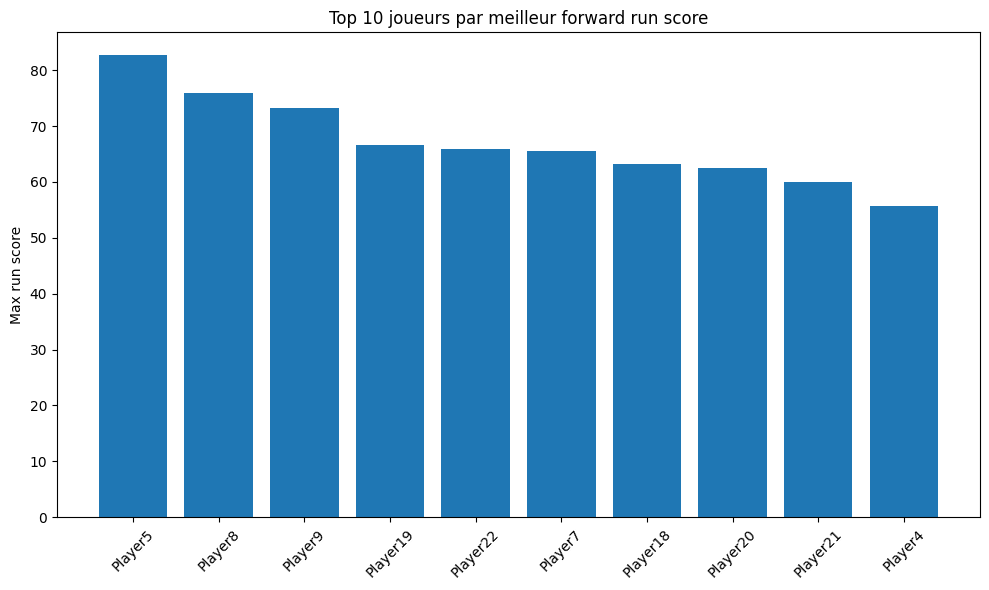

In [48]:
import matplotlib.pyplot as plt

top10_max = player_summary.sort_values("max_run_score", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_max["player"], top10_max["max_run_score"])
plt.xticks(rotation=45)
plt.ylabel("Max run score")
plt.title("Top 10 joueurs par meilleur forward run score")
plt.tight_layout()
plt.show()

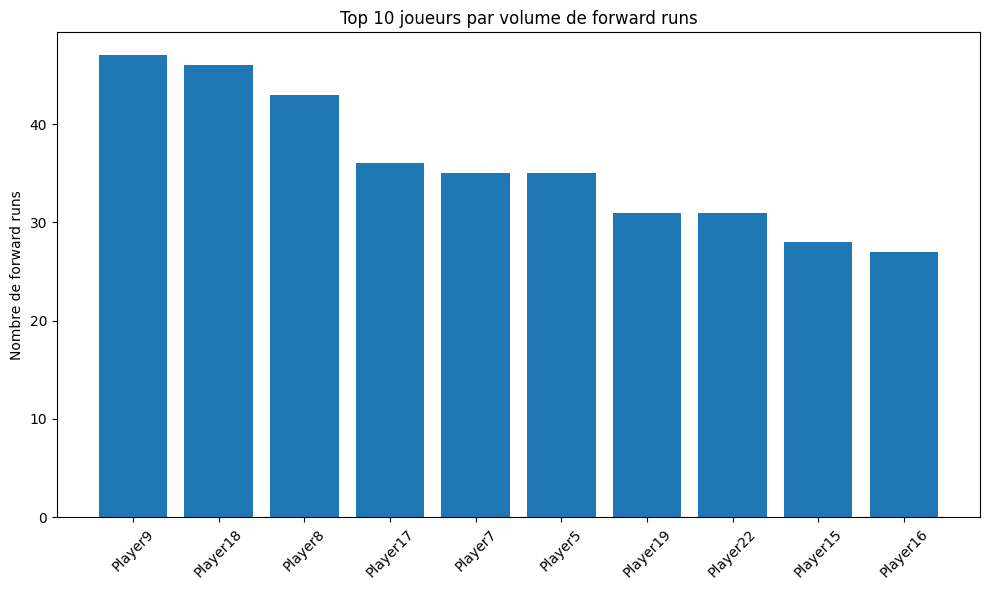

In [49]:
top10_volume = player_summary.sort_values("n_forward_runs", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_volume["player"], top10_volume["n_forward_runs"])
plt.xticks(rotation=45)
plt.ylabel("Nombre de forward runs")
plt.title("Top 10 joueurs par volume de forward runs")
plt.tight_layout()
plt.show()

# 11. Visualisations

Deux graphiques simples ont été utilisés pour rendre les résultats plus lisibles :

- le top 10 des joueurs par **meilleur forward run score**
- le top 10 des joueurs par **volume de forward runs**

Ces visualisations permettent de distinguer rapidement :
- les joueurs de pic,
- et les joueurs de volume.

Elles constituent une première brique de restitution visuelle dans une logique de profiling ou de scouting.

# 12. Limites du projet

Ce prototype présente plusieurs limites importantes.

## 1. Sens d’attaque non modélisé explicitement

La progression vers l’avant a ici été approximée par `delta_x > 0`.  
Dans une version plus robuste, le sens d’attaque devrait être défini explicitement par période et par équipe.

## 2. Définition heuristique des seuils

Les seuils utilisés pour :
- la vitesse,
- la durée,
- la distance,
- l’orientation

ont été choisis de manière simple et interprétable, mais n’ont pas été optimisés à partir de labels experts.

## 3. Score simplifié

Le score proposé repose sur une combinaison manuelle de variables et d’un bonus événementiel.  
Une version plus avancée pourrait apprendre automatiquement la valeur d’une course à partir de données annotées.

## 4. Absence de contexte tactique complet

Le projet ne modélise pas encore :
- la ligne défensive adverse,
- les espaces entre les lignes,
- la proximité du ballon,
- ou la densité locale autour du joueur.

Il s’agit donc d’une première brique de détection et non encore d’une métrique complète de "run in behind".

# 13. Perspectives

Plusieurs prolongements naturels sont possibles pour rapprocher ce prototype d’une problématique réelle de Game Intelligence.

## 1. Intégrer le sens de jeu par période
Permettre une définition robuste de la progression offensive selon l’équipe et la mi-temps.

## 2. Détecter les "runs in behind"
Comparer la trajectoire du joueur à la ligne défensive adverse afin d’identifier les courses qui attaquent réellement la profondeur.

## 3. Ajouter un contexte spatio-tactique plus riche
Par exemple :
- distance au ballon,
- proximité des défenseurs,
- occupation des demi-espaces,
- accès à une ligne de passe.

## 4. Améliorer la valorisation des courses
Remplacer le score heuristique par :
- une calibration supervisée,
- un modèle probabiliste,
- ou un modèle séquentiel sur fenêtres temporelles.

## 5. Étendre l’analyse à plusieurs matchs
Le projet actuel repose sur un sample match.  
Une validation sur plusieurs matchs permettrait d’évaluer la robustesse et la généralisation de la méthode.

# 14. Conclusion

Ce notebook propose une première approche de détection et de valorisation de courses offensives à partir de tracking data de type broadcast.

À partir du dataset Metrica Sports, une pipeline complète a été construite pour :

- préparer et nettoyer les données,
- calculer les vitesses,
- détecter des séquences de course,
- filtrer les forward runs strictes,
- contextualiser ces courses avec les événements du match,
- produire une agrégation au niveau joueur.

Même si la méthode reste volontairement simple, elle montre qu’il est possible d’extraire automatiquement des comportements de projection offensive pertinents à partir de données spatio-temporelles.

Ce travail constitue une première étape crédible vers des métriques plus avancées, comme :
- la détection d’appels dans la profondeur,
- l’analyse des disponibilités entre les lignes,
- ou l’évaluation de la valeur tactique des mouvements sans ballon.